## Chain Line extraction from images of transmitted light manuscripts
### 0. Load matlab files
### you can take one of the test files that are in the file called: file matlab usefuls

In [47]:
#%pip install numpy scipy matplotlib ipywidgets  # ----packages needed to run the algorithm, you can install it in your console uncommenting this line----- 
#this is in case you don’t have the packages installed on your system

In [48]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d, rotate
from skimage.transform import radon
import time
import ipywidgets as widgets
from IPython.display import display
import warnings

### 1. Pre-processing
It is necessary to pass the image through the **magic eraser** tool and obtain the result.

Therefore, the image must be cut by hand with a size around 350 height x the full width of the image; it must be done without exceeding the range of 300 to 400 pixels in size to maintain optimal performance.

Then must be passed through the pixel measurement algorithm and the obtained value corresponding to the number of pixels found in 10 millimeters **must be entered into section Chain line distance measuring** of this document.

### 2. Patch selection
For patch selection select the area of the image that has the best quality without so much interference as folds, spots or holes that can alter the result.

### 3. Spectral TV decomposition
The code used in this project is based on the algorithme of: e.g. Gilboa et al. (https://guygilboa.net.technion.ac.il/2020/10/09/spectral-total-variation-color/) in Matlab. 

The matlab code adaptated is also disponible in this folder with the name of: **SepcTv_color_algorithm.** you can use the images included in the folder to run the code in a **Matlab environment** to prove it.

Run the matlab code first and load the document matlab document containing the result of the descomposed image here next.

#### 3.1 Load Data

In [49]:
time_start=time.perf_counter()
u_0 = sio.loadmat(r'Files_matlab_usefuls\filtered_manuscript_1-Cut1.mat') # <----- <<---BLANK SPACE FOR THE MATLAB FILE
#Enter the relative address of the file to run here from the files folder: files_matlab_usefuls

dec_phi = u_0['f_H'] 
img_ready= np.moveaxis(dec_phi, -1, 0)
num_bands=8

### 4. Fourier Filtering
Enhance chain lines in the frequency domain. First, we define functions for filtering and plotting the filtered images. The rectangularFilter function has the option for vertical and horizontal filtering. The filter_dir should be perpendicular to the chain line direction and depends on the orientation of the image.

In [50]:
# Define rectangular filter for Fourier filtering 
class rectangleFilter:
    def __init__(self, filter_dir, imgShape):
        self.filter_dir = filter_dir
        self.imgShape = imgShape
    
    def __call__(self, length, width, low_cut=20):
        # filter_dir is based on the orientation of the image. 
        # The filter_dir should be perpendicular to the chain line direction
        base = np.zeros(self.imgShape[:2])
        rows, cols = self.imgShape[:2]
        center_row, center_col = int(rows/2), int(cols/2)
        
        if self.filter_dir == 'vertical': 
            base[length:rows-length, center_col-width:center_col+width] = 1
            # Elimination of the DC component and global lighting variations
            base[center_row-low_cut:center_row+low_cut, center_col-width:center_col+width] = 0
            
        elif self.filter_dir == 'horizontal':
            base[center_row-width:center_row+width, length:cols-length] = 1
            # Elimination of the DC component and global lighting variations
            base[center_row-width:center_row+width, center_col-low_cut:center_col+low_cut] = 0
            
        else:
            print('Error, please select either vertical or horizontal')
        
        return base
    
# Define plotting class
class plot_FFT:
    def __init__(self, Filter, save='False'):
        self.Filter = Filter
        self.save = save
        
    def __call__(self, img, width, length, low_cut=20):
        original = np.fft.fft2(img)
        center = np.fft.fftshift(original) #To replace the low frequency in the center of the fourier domain image (especially the dc component or frequency 0))
        magnitude_spec = np.log(1+np.abs(center)) # Here the frequency spectrum is transformed on a logarithmic scale with low frequencies in the center (usually the second image of the first row ) also within the function in parenting the handling of the complex signal (Fourier transform works with complex frequencies)
        
        fig, axes = plt.subplots(2, 3, figsize=(25,6), constrained_layout=False)
        ax_row = axes[0]
        ax_row[0].imshow(img, "gray")
        ax_row[0].set_title('Spectral TV Image')
        ax_row[0].axis('off')
        ax_row[1].imshow(magnitude_spec, "gray")
        ax_row[1].set_title("Centered Spectrum")
        ax_row[1].axis('off')
        
        # Filter applied for display
        LowPassCenter = center * self.Filter(length, width, low_cut)
        ax_row[2].imshow(np.log(1+np.abs(LowPassCenter)), "gray")
        ax_row[2].set_title("Centered Spectrum multiply Band Pass Filter")
        ax_row[2].axis('off')
        
        ax_row = axes[1]
        
        # Image 1: Width Original, corresponds to the first image of the second row
        LowPass1 = np.fft.ifftshift(center * self.Filter(length, width, low_cut))
        inverse1 = np.fft.ifft2(LowPass1)
        ax_row[0].imshow(np.abs(inverse1), "gray")
        ax_row[0].set_title(f"Processed: length {length}, width {width}")
        ax_row[0].axis('off')
        
        # Image 2: Medium contrast, corresponds to the second image of the second row
        width_2 = max(1, width - 1) 
        LowPass2 = np.fft.ifftshift(center * self.Filter(length, width_2, low_cut))
        inverse2 = np.fft.ifft2(LowPass2)
        ax_row[1].imshow(np.abs(inverse2), "gray")
        ax_row[1].set_title(f"Processed: length {length}, width {width_2}")
        ax_row[1].axis('off')
        
        # Image 3: High contrast, corresponds to the third image of the second row
        width_3 = max(1, width - 2)
        LowPass3 = np.fft.ifftshift(center * self.Filter(length, width_3, low_cut))
        inverse3 = np.fft.ifft2(LowPass3)
        ax_row[2].imshow(np.abs(inverse3), "gray")
        ax_row[2].set_title(f"Processed: length {length}, width {width_3}")
        ax_row[2].axis('off')
        
        if self.save == 'True':
            plt.savefig('FILE_NAME.png')
        plt.show()
        plt.close(fig)



Next, we initialise the filter and plotting functions for the decomposed image. In some cases it may be necessary to rotate the image as well for ease of analysis. We choose length and width for the filtering based on the image size. The plotter will render results for width, width-1 and width-2.

In [51]:
# --- execution-----
@widgets.interact(
    image_rotation= widgets.Checkbox(value=False, description="Rotate the image 90°")
)
def interactive_fourier(image_rotation):

    global img_ready, width, length, low_cut_value,plotter,Filter

    img_ready = dec_phi 

    if image_rotation == True:
        img_ready =  rotate(dec_phi,90) # <-----adjustable parameter---- 

    #If the orientation of the image is horizontal, the rotation is necessary to be applied; 
    #for this purpose, selects the button below this code block to rotate the image

    if len(img_ready.shape) == 3:
        img_ready = np.mean(img_ready, axis=2)

    Filter = rectangleFilter(filter_dir = 'horizontal',imgShape = img_ready.shape)
    plotter = plot_FFT(Filter,save='False') # initialise plotter

    length = 100 #  ----adjustable parameter----
    width = 3 #  ----adjustable parameter----  here the band pass filter is set, in this case with a maximum of 3 pixels wide  (we didn't adjust it because that works with that value)
    low_cut_value = 30 #  ----adjustable parameter----  This value is adjusted. The value 30 corresponds to the DC component for the removal of white spots belonging to the overall brightness of the image that generate noise when detecting the chain lines
    plotter(img_ready,width,length,low_cut_value)
    

interactive(children=(Checkbox(value=False, description='Rotate the image 90°'), Output()), _dom_classes=('wid…

Based on the filtering results, we choose the width that render the best filtered results to use in the rest of the analysis

In [52]:
@widgets.interact(
    best_width=widgets.Dropdown(options=[1, 2, 3],       
        value=1,                
        description='Best width:',
        style={'description_width': 'initial'}
    )
)
def decision_fourier(best_width):

    global original, center, LowPassCenter, inverse_LowPass
    # ===================================
    # ==== IMPORTANT VISUAL DECISION ====
    # ===================================
    # Based on the 3 graphs from the previous step, the number is written below 
    # that gave the best result by isolating the chain lines, in most cases will be the value 1
    
    print(f"=" * 80)
    print(f"if one of the 3 images has better results when showing the chain lines please change the best width selecting its corresponding number")

    best_width = best_width  # ----adjustable parameter---- among: 1,2,3

    # 1.Fourier transform application
    original = np.fft.fft2(img_ready) 
    center = np.fft.fftshift(original)

    # 2. The final filter is applied using the exact choice
    LowPassCenter = np.fft.ifftshift(center * Filter(length, best_width)) 

    # 3. Reverse transformation and absolute value extraction (actual pixels)
    inverse_LowPass = np.abs(np.fft.ifft2(LowPassCenter))

    print(f"Permanent filter applied with a thickness of: {best_width}")

interactive(children=(Dropdown(description='Best width:', options=(1, 2, 3), style=DescriptionStyle(descriptio…

### 5. Cross section (Angle detection)
Here we are able to detect the inclination angle of the chain lines with the objetive to draw the lines with the correct angle inclination

The inclination angle of Chain Lines is: 0.00 degrees


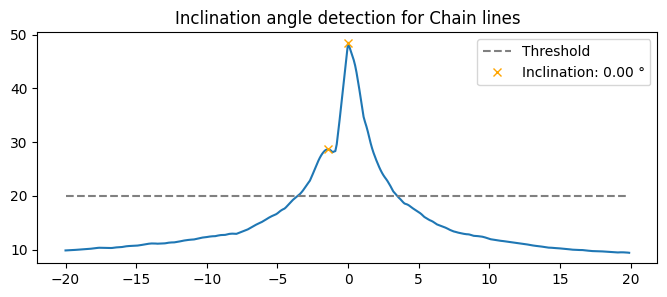

In [53]:
warnings.filterwarnings("ignore", message="Radon transform: image must be zero outside the reconstruction circle")

img_angle= np.abs(inverse_LowPass)

#the angle vector is created and the radon transform applied
theta= np.linspace(-20.,20.,400, endpoint=False)
sinogram = radon(img_angle, theta=theta)

#cross-section to find the inclination angle

x =[] #for angles
y =[] #for intensities

for i in range (theta.shape[0]):
    y.append(np.max(sinogram[:,i]))
    x.append(theta[i])
y =np.array(y)
x= np.array(x)

#height of the threshold to detect the peaks which hold the best inclination angle
height_ang =20
peaks_y, _ = find_peaks(y, height=height_ang)


if len(peaks_y) > 0:
    #We select the peak of greatest intensity
    best_peak_idx = peaks_y[np.argmax(y[peaks_y])]

    thet_idx = x[best_peak_idx]
    print(f"The inclination angle of Chain Lines is: {thet_idx:.2f} degrees")
else:
    print("Warning:  No inclination angle detected.")

#View the angle graph 
fig, ax = plt.subplots(1,1, figsize=(8, 3))
ax.plot(x, y)

ax.plot(x, height_ang * np.ones_like(x), "--", color="gray", label='Threshold')
ax.plot(x[peaks_y], y[peaks_y], "x", color="orange", label=f"Inclination: {thet_idx:.2f} °")
ax.set_title("Inclination angle detection for Chain lines")
ax.legend()
plt.show()


### 6. Verticale Projection and Peak detection

Project the filtered image onto the relevant axis.
Locate peaks with highest magnitude, representing the chain lines. The variable "height" represents the cut-off threshold and is to be chosen manually. We include gaussian smoothing of the 1D signal to filter out noise.

In [54]:
y = np.sum(np.abs(inverse_LowPass), axis=0) #  ----adjustable parameter----  change to axis=1 for vertical filter
x = np.linspace(0,y.shape[0],y.shape[0]) 

In [55]:
@widgets.interact(
    min_dist_px= widgets.IntSlider(min=10, max=200, step=5, value=70, description="minimun distance pixeles: " ,style={"description_width": "initial"} ),

    lateral_margin= widgets.IntSlider(min=0, max=8, step=1, value=2, description="Lateral pixeles margin: " ,style={"description_width": "initial"} )
)
def interactive_peak_detection(min_dist_px, lateral_margin):
    global peaks_y

    min_dist_px=min_dist_px
    margin=lateral_margin

    fil=1
    sigma = 2 # standard deviation of the gaussian kernel for filtering
    if fil ==1:
        y_ = gaussian_filter1d(y,sigma) # smoothing of the signal
    else:
        y_ = y


    y_cropped=y_[margin:-margin]
    x_cropped=x[margin:-margin]

    height=np.percentile(y_cropped, 90) #<------ automatique threshold

    print(f"The threshold height established is: {height:.1f}")

    peaks_y_relatives,_= find_peaks(y_cropped,height=height, distance=min_dist_px)

    peaks_y= peaks_y_relatives +  margin

    # Plot the detected peaks in the signal
    fig, ax = plt.subplots(1, 1, figsize=(15, 4))
    ax.plot(x,y_)
    ax.plot(x[peaks_y],y_[peaks_y], "x", label="Chain lines detected")
    ax.plot(x,height*np.ones_like(x), "--", color="gray", label=f"threshold: {height:.1f}")
    ax.legend()
    plt.show()
    plt.close(fig)


interactive(children=(IntSlider(value=70, description='minimun distance pixeles: ', max=200, min=10, step=5, s…

### 7. Chain line distance measuring and plotting

In [56]:
@widgets.interact(
    pixels_in_10mm= widgets.FloatText(value=65.40, description="Pixeles in 10 mm: ", step=0.1, style={"description_width":"initial"})
)
def interactive_calcule(pixels_in_10mm):
    try:
        if pixels_in_10mm <=0:
            print("Expecting a value greater than 0...")
            return
        
        scale_factor=1
         #  ----adjustable parameter---- this value can change taking into account an algorithm to detect how many pixels there are in 1 millimeter
        px_per_mm= pixels_in_10mm/10

        patch_height=(dec_phi.shape[0] )
        patch_width=(dec_phi.shape[1])

        patch_pixels_size_mm_w= patch_width
        patch_pixels_size_mm_h= patch_height

        #calculation of numbers of chain lines
        num_lines= len(peaks_y)

        patch_size_mm_h= patch_pixels_size_mm_h / px_per_mm
        patch_size_mm_w= patch_pixels_size_mm_w / px_per_mm

        # to calculate the distance beetwen each chain line
        distances_px = np.diff(peaks_y)
        distances_mm = (distances_px / px_per_mm)


        print(f"The size patch is: {patch_width} width x {patch_height } height in pixels")
        print(f"The patch size in millimeters is: {patch_size_mm_w:.1f} mm width, {patch_size_mm_h:.1f} mm height")
        print(f"There are: {len(peaks_y)} lines in this patch")
        print(f"The chainline distances in millimeters are: {np.round(distances_mm, 1)}")
        print(f'Mean distance: {np.mean(distances_mm):.1f} mm')

    except NameError as e:
        print(f"ERROR: Previous cell to run is missing. Variable not found:{e}")
    except Exception as e:
        print(f"Unexpected error: {e}")



interactive(children=(FloatText(value=65.4, description='Pixeles in 10 mm: ', step=0.1, style=DescriptionStyle…

In [58]:
@widgets.interact(
    final_image_rotation= widgets.Checkbox(value=False, description="Rotate the image 90°")
)
def final_interactive_fourier(final_image_rotation):
    # Plot over the original image

    image_3d = dec_phi.copy().astype(np.float32)

    if final_image_rotation ==True:
        image_3d=rotate(image_3d,90) 

    # Normalize the color image for proper processing (values from 0 to 1) with the objective to show the original image in colors and not in grayscale
    image_3d_norm = (image_3d - np.min(image_3d)) / (np.max(image_3d) - np.min(image_3d))

    height, width = image_3d_norm.shape[:2]

    fig,(ax1,ax2)=plt.subplots(2,1, figsize=(15,9))

    ax1.set_title("Original", fontsize=13)
    ax1.imshow(image_3d_norm, aspect="auto")
    ax1.axis("off")


    ax2.set_title("Chain Lines Detection", fontsize=13)
    ax2.imshow(image_3d_norm, aspect="auto")
    ax2.axis("off")

    #transforme l'angle detecté en radianes
    angle_rad=np.deg2rad(thet_idx)

    y_center= height / 2

    # Draw the detected lines
    for peak in peaks_y:

        #is defined where the axis line (y) starts and ends from top to bottom
        y_start= 0
        y_end= height

        #the coordinate of x of these points is calculated using the tangent of the angle
        #x= central_peak + distance_y * tan(angle)
        x_start = peak +(y_center - y_start) * np.tan(-angle_rad)
        x_end = peak + (y_center - y_end) * np.tan(-angle_rad)


        ax2.plot([x_start, x_end], [y_start, y_end], color='crimson', linewidth=3, linestyle='-', alpha=0.8)


    plt.show()

time_end=time.perf_counter()
total_time=time_end-time_start

seconds = total_time % 60

print("-" *40)
print(f"Total time execution: {seconds:.2f} seconds")


interactive(children=(Checkbox(value=False, description='Rotate the image 90°'), Output()), _dom_classes=('wid…

----------------------------------------
Total time execution: 50.71 seconds
